# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

from scipy.special import expit
from sklearn.linear_model import LogisticRegression, Lasso 

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from core.dgp import DataGenerationProcess, Targeting
from core.targeting import *
from core.variables import *

# DGP

In [15]:
dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

# dgp_params = {
#     'base_effects': [PointMass(0.1), PointMass(0.11)], 
#     'cust_feat_var': Uniform(0, 1), 
#     'char_func': lambda x: x**2 + x, 
#     'response_type': 'bernoulli', 
#     'dgp_seed': 0
# }

# instantiate the DGP
dgp = Targeting(**dgp_params)

In [16]:
# sample 
cust_features, treatments, outcomes = dgp.sample(1000)
oos_cust_features = dgp.sample_individuals(1000)

# Estimation

In [21]:
cfdml = CausalForestDML(
    n_treatments=2, model_t=LogisticRegression(C=0.01), model_y=Lasso(alpha=0.01), 
    n_estimators=100, max_depth=5, n_jobs=-1, discrete_treatment=True
).fit(X=cust_features, Y=outcomes, T=treatments)

emp_targ_te_arr, emp_targ_var_arr = cfdml.predict_incremental_effect(oos_cust_features)

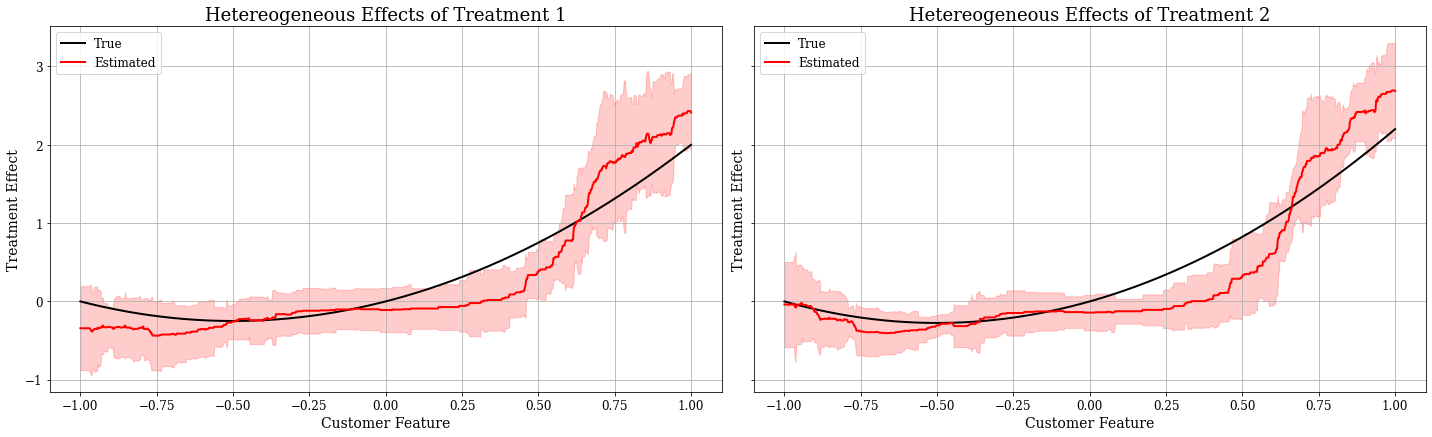

In [22]:
plot_hte(dgp, model=cfdml, ci=True)

# Selection

In [23]:
selection, val_est = optimize(cfdml, oos_cust_features)

# Evaluation

In [51]:
val_true = obj_func(
    selection=selection, 
    cust_feautres=oos_cust_features, 
    demand_model=dgp,
)

result_df = pd.DataFrame({
    'Policy Value': [val_est, val_true, val_est - val_true]
}, index=['Estimated', 'True', "Winner's Curse"])
result_df

,Policy Value
Estimated,0.981969
True,1.028681
Winner's Curse,-0.046713


In [52]:
del dgp, cfdml, selection, val_est, val_true, result_df 
del cust_features, treatments, outcomes, oos_cust_features

# Winner's Curse

In [13]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 1000} 

experiment_params = {
    'n_repeats': 100, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {}

In [13]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 100 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    8.7s finished


In [14]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / data_params['sample_size'] ** 0.5 

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')


Selection with Rank and Select:
  - Average True Value: 1.0681 (0.0018)
  - Average Estimated Value: 1.1460 (0.0030)
  - Average Winner's Curse (%): 77.87% (2.53%)


# Estimating Winner's Curse

In [14]:
dgp = Targeting(**dgp_params)

cust_features, treatments, outcomes = dgp.sample(data_params['sample_size'])
oos_cust_features = dgp.sample_individuals(data_params['sample_size'])

## Standard Bootstrap

In [20]:
boot_wc_dstn_dict = get_wc_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=100, 
    emp_targ_te_arr=None, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    6.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    8.1s finished


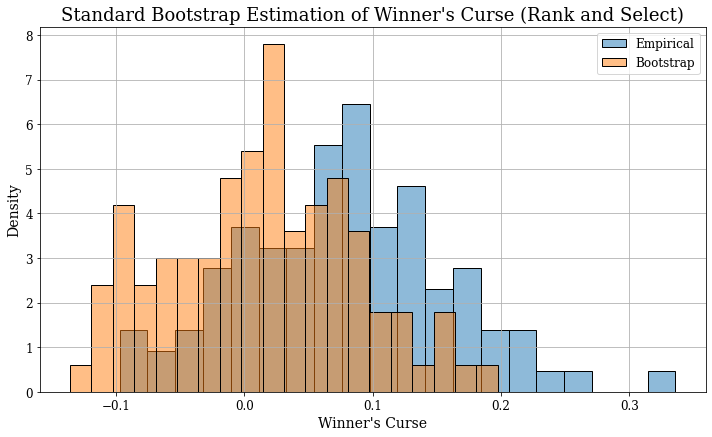

In [21]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.set_title(f'Standard Bootstrap Estimation of Winner\'s Curse ({display_name})', fontsize=title_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [22]:
boot_wc_dstn_dict = get_wc_m_out_of_n_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=100, 
    emp_targ_te_arr=None, 
    power=0.95, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    1.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.7s finished


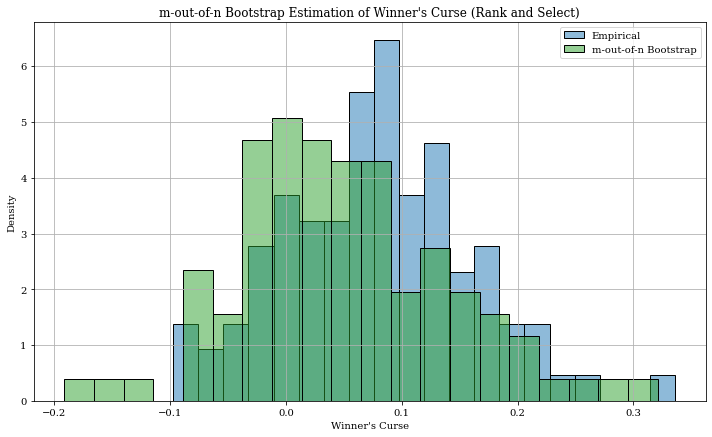

In [23]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'm-out-of-n Bootstrap Estimation of Winner\'s Curse ({display_name})')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [24]:
boot_wc_dstn_dict = get_wc_num_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=100, 
    emp_targ_te_arr=None, 
    power=-0.45, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:    1.2s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    3.0s finished


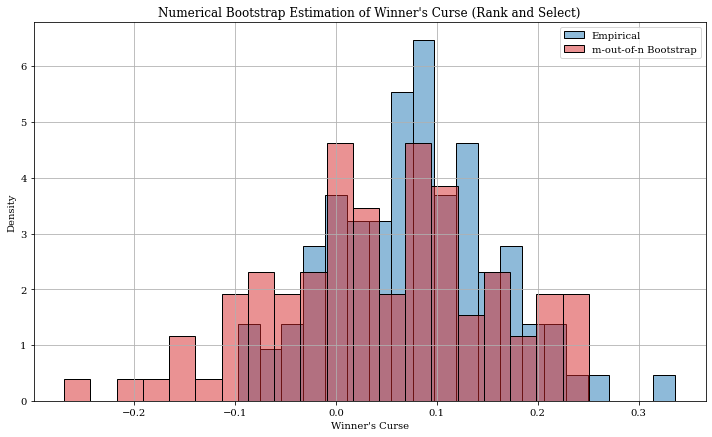

In [25]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'Numerical Bootstrap Estimation of Winner\'s Curse ({display_name})')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [56]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 1000} 

experiment_params = {
    'n_repeats': 1, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'cond_selective_inference': {
        'estimator': conditional_selective_inference_estimate,
        'params': {'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': '(Andrews et al. 2024)'
    }
}

In [54]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 1 experiments...


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   17.9s finished



Selection with Rank and Select:
Policy Value: 
  - True Value: 1.1206 (0.0000)
  - No Correction: 1.0563 (0.0000)
  - Standard Bootstrap: 0.9973 (0.0000)
  - m-out-of-n Bootstrap: 0.9988 (0.0000)
  - Numerical Bootstrap: 0.9596 (0.0000)
  - (Andrews et al. 2024): -0.4735 (0.0000)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: -64.31% (0.00%)
  - Standard Bootstrap: -123.30% (0.00%)
  - m-out-of-n Bootstrap: -121.80% (0.00%)
  - Numerical Bootstrap: -161.04% (0.00%)
  - (Andrews et al. 2024): -1594.10% (0.00%)
Median Winner's Curse: 
  - No Correction: -64.31% (0.00%)
  - Standard Bootstrap: -123.30% (0.00%)
  - m-out-of-n Bootstrap: -121.80% (0.00%)
  - Numerical Bootstrap: -161.04% (0.00%)
  - (Andrews et al. 2024): -1594.10% (0.00%)

Sample Splitting: 
  - True Value: 1.1177 (0.0000)
  - Estimated Value: 0.9819 (0.0000)
  - Winner's Curse (%): -135.81% (0.00%)


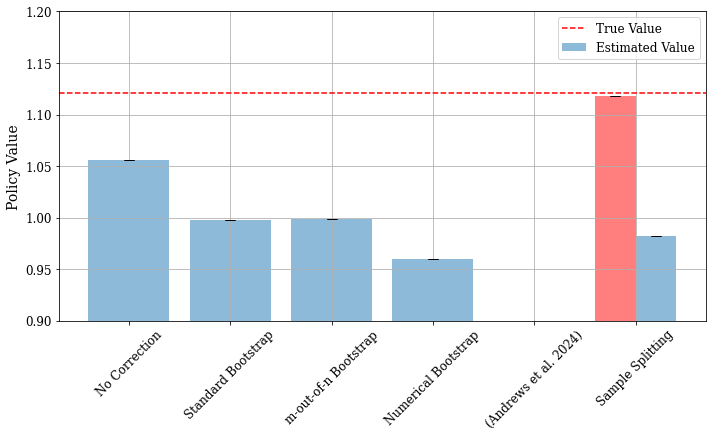

In [55]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

optimizer_key = 'rank_and_select'

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()]
    )
ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()
